# ABSA Model Training (dual-head)

Shared encoder (DistilBERT) with per-aspect heads:
- **Mention head** — binary: notmentioned vs mentioned
- **Sentiment head** — 3-class: positive / neutral / negative

Training uses HuggingFace Trainer with Focal loss, cosine LR, and early stopping.
Best checkpoint selected by `sentiment_macro_f1_mentioned`.

In [1]:
%load_ext autoreload
%autoreload 2

import json, os
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import torch
import transformers
from transformers import AutoTokenizer, set_seed

from config.global_config import MAX_LENGTH, SENTIMENT_3, TRAIN_ASPECTS
from model.choose_architecture import get_device
from model.model import ABSAModel, ARCHITECTURE_VERSION
from model.prepare_dataset import ABSADataset, mention_distribution, oversample_mentions, stratified_split
from model.threshold_tuning import tune_mention_threshold
from model.train import compute_mention_class_weights, compute_sentiment_class_weights, train_model

transformers.logging.set_verbosity_error()

/Users/bartoszbugla/projects/projekt-magisterski/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ── Configuration ──────────────────────────────────────────────
QUICK_RUN = False                # flip to False for full training

MODEL_NAME  = "bert-base-uncased"
# MODEL_NAME  = "distilbert-base-uncased-finetuned-sst-2-english"
DATA_PATH   = "statics/datasets/training.csv"
SAVE_DIR    = "saved_models"
SEED        = 25

NUM_EPOCHS  = 1 if QUICK_RUN else 7
BATCH_SIZE  = 16 if QUICK_RUN else 32
LR          = 2e-5
PATIENCE    = 1 if QUICK_RUN else 2
GRAD_ACCUM  = 1 if QUICK_RUN else 2
OVERSAMPLE  = 0.0 if QUICK_RUN else 0.5
FOCAL_GAMMA = 2.0
LABEL_SMOOTH = 0.05
MAX_ROWS    = 256 if QUICK_RUN else None

OUTPUT_DIR = "./absa_results_quick" if QUICK_RUN else "./absa_results"
safe_name  = MODEL_NAME.replace("/", "_")

set_seed(SEED)
print(f"QUICK_RUN={QUICK_RUN}  model={MODEL_NAME}  epochs={NUM_EPOCHS}  batch={BATCH_SIZE}")

QUICK_RUN=False  model=bert-base-uncased  epochs=5  batch=32


## 1. Data loading & split

In [3]:
df = pd.read_csv(DATA_PATH)
df[TRAIN_ASPECTS] = df[TRAIN_ASPECTS].fillna("notmentioned")
if MAX_ROWS:
    df = df.head(MAX_ROWS).reset_index(drop=True)

train_df, val_df = stratified_split(df, val_ratio=0.2, seed=SEED)

if OVERSAMPLE > 0:
    n_before = len(train_df)
    train_df = oversample_mentions(train_df, factor=OVERSAMPLE, seed=SEED)
    print(f"Oversampled: {n_before} → {len(train_df)}")

print(f"Train: {len(train_df)}, Val: {len(val_df)}")
print("Mentioned per aspect:", mention_distribution(train_df))

Oversampled: 3400 → 5088
Train: 5088, Val: 851
Mentioned per aspect: {'safety': 313, 'cleanliness': 589, 'infrastructure': 1401, 'nature': 955, 'attractions': 2292, 'heritage': 825, 'costs': 551, 'other': 3864}


## 2. Tokenization & class weights

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_ds  = ABSADataset(train_df, tokenizer, max_length=MAX_LENGTH)
val_ds    = ABSADataset(val_df, tokenizer, max_length=MAX_LENGTH)

sent_w = compute_sentiment_class_weights(train_ds.get_sentiment_labels_numpy())
ment_w = compute_mention_class_weights(train_ds.get_mention_labels_numpy())
print(f"Sentiment weights: {sent_w}")
print(f"Mention weights:   {ment_w}")

ABSADataset: 5088 examples, aspects=8, sentiments=3 (+ ignore)
ABSADataset: 851 examples, aspects=8, sentiments=3 (+ ignore)
Sentiment weights: tensor([0.4367, 4.8602, 1.9831])
Mention weights:   tensor([0.6776, 1.9073])


## 3. Model creation

In [5]:
model = ABSAModel(
    MODEL_NAME,
    num_aspects=len(TRAIN_ASPECTS),
    num_sentiment_classes=len(SENTIMENT_3),
    sentiment_class_weights=sent_w,
    mention_pos_weight=ment_w,
    focal_gamma=FOCAL_GAMMA,
)
total  = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total:,}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8937.81it/s]

Parameters: 109,514,536


## 4. Training

In [6]:
trainer = train_model(
    model, train_ds, val_ds,
    tokenizer=tokenizer,
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    label_smoothing_factor=LABEL_SMOOTH,
    early_stopping_patience=PATIENCE,
    seed=SEED,
)

{'loss': '1.51', 'grad_norm': '4.346', 'learning_rate': '4.5e-06', 'epoch': '0.1258'}
{'loss': '1.251', 'grad_norm': '2.898', 'learning_rate': '9.5e-06', 'epoch': '0.2516'}
{'loss': '1.046', 'grad_norm': '3.124', 'learning_rate': '1.45e-05', 'epoch': '0.3774'}
{'loss': '0.8918', 'grad_norm': '2.314', 'learning_rate': '1.95e-05', 'epoch': '0.5031'}
{'loss': '0.836', 'grad_norm': '2.259', 'learning_rate': '1.997e-05', 'epoch': '0.6289'}
{'loss': '0.7604', 'grad_norm': '3.363', 'learning_rate': '1.986e-05', 'epoch': '0.7547'}
{'loss': '0.7028', 'grad_norm': '2.687', 'learning_rate': '1.968e-05', 'epoch': '0.8805'}
{'loss': '0.7104', 'grad_norm': '3.063', 'learning_rate': '1.943e-05', 'epoch': '1'}
{'eval_loss': '0.6861', 'eval_sentiment_macro_f1_mentioned': '0.6025', 'eval_detection_f1': '0.6938', 'eval_overall_macro_f1': '0.5296', 'eval_runtime': '4.588', 'eval_samples_per_second': '185.5', 'eval_steps_per_second': '3.051', 'epoch': '1'}
{'loss': '0.5971', 'grad_norm': '2.18', 'learning_

## 5. Training curves

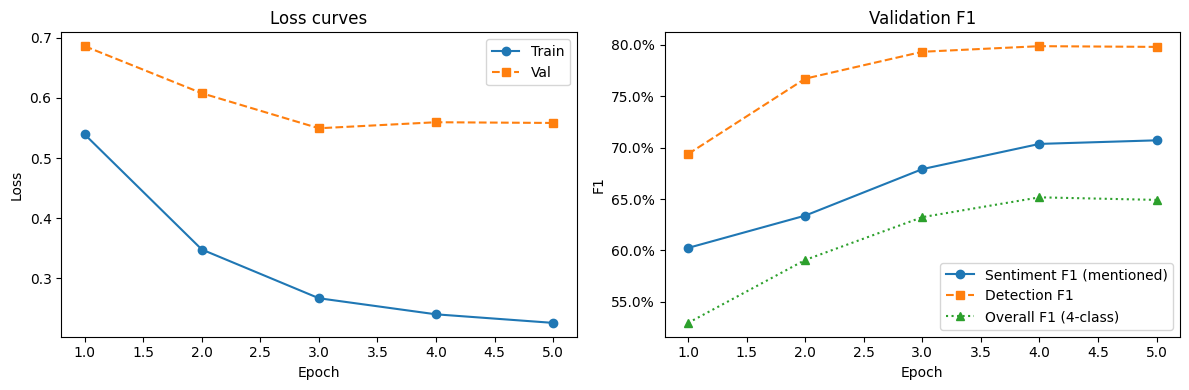

Best epoch 5: sentiment_f1=0.7071, detection_f1=0.7980, overall=0.6492


In [7]:
# Parse Trainer log into per-epoch history
train_losses = defaultdict(list)
eval_logs = {}
for e in trainer.state.log_history:
    ep = int(e.get("epoch", 0))
    if "loss" in e and "eval_loss" not in e:
        train_losses[ep].append(e["loss"])
    elif "eval_loss" in e:
        eval_logs[ep] = e

history = []
for ep in sorted(eval_logs):
    ev = eval_logs[ep]
    tl = train_losses.get(ep, [])
    history.append({
        "epoch": ep,
        "train_loss": sum(tl) / len(tl) if tl else None,
        "eval_loss": ev.get("eval_loss"),
        "sentiment_f1": ev.get("eval_sentiment_macro_f1_mentioned"),
        "detection_f1": ev.get("eval_detection_f1"),
        "overall_f1":   ev.get("eval_overall_macro_f1"),
    })

h = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(h["epoch"], h["train_loss"], "o-", label="Train")
ax1.plot(h["epoch"], h["eval_loss"],  "s--", label="Val")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss curves")
ax1.legend()

ax2.plot(h["epoch"], h["sentiment_f1"], "o-",  label="Sentiment F1 (mentioned)")
ax2.plot(h["epoch"], h["detection_f1"], "s--", label="Detection F1")
ax2.plot(h["epoch"], h["overall_f1"],   "^:",  label="Overall F1 (4-class)")
ax2.set(xlabel="Epoch", ylabel="F1", title="Validation F1")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.legend()

plt.tight_layout()
plt.show()

best = h.loc[h["sentiment_f1"].idxmax()]
print(f"Best epoch {int(best['epoch'])}: sentiment_f1={best['sentiment_f1']:.4f}, "
      f"detection_f1={best['detection_f1']:.4f}, overall={best['overall_f1']:.4f}")

## 6. Threshold tuning & save

In [8]:
device = get_device()
threshold, stats = tune_mention_threshold(
    model, tokenizer, val_ds, device=device, batch_size=max(32, BATCH_SIZE),
)
print(f"Best mention threshold: {threshold:.3f}", stats)

os.makedirs(SAVE_DIR, exist_ok=True)
save_path = os.path.join(SAVE_DIR, f"{safe_name}_absa.pt")

torch.save({
    "model_state_dict":    model.state_dict(),
    "base_model_name":     MODEL_NAME,
    "architecture_version": ARCHITECTURE_VERSION,
    "aspects":             TRAIN_ASPECTS,
    "sentiment_labels":    SENTIMENT_3,
    "mention_threshold":   threshold,
}, save_path)
print(f"Saved → {save_path}")

with open(os.path.join(SAVE_DIR, f"{safe_name}_history.json"), "w") as f:
    json.dump({"epochs": history, "threshold": threshold, "threshold_stats": stats}, f, indent=2)
print("History saved.")

Using device: mps
Best mention threshold: 0.425 {'sentiment_macro_f1_mentioned': 0.6845844729559326, 'detection_f1': 0.7918905715681485, 'combined_score': 0.7221416074702082}
Saved → saved_models/bert-base-uncased_absa.pt
History saved.


## 7. Quick inference test

In [9]:
from predictions.prediction_fine_tuned import FineTunedModel

ft = FineTunedModel(aspects=TRAIN_ASPECTS, local_model_path=save_path)

for text in [
    "This park is dirty and unsafe at night, the paths are broken.",
    "Beautiful museum with free entry and amazing historical exhibitions!",
]:
    preds = ft.predict(text)
    active = {k: v for k, v in preds.items() if v != "notmentioned"}
    print(f"\n>>> {text}")
    print(f"  {active if active else '(no aspects detected)'}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8387.01it/s]


Using device: mps

>>> This park is dirty and unsafe at night, the paths are broken.
  {'safety': 'negative', 'cleanliness': 'negative', 'infrastructure': 'negative', 'nature': 'negative', 'other': 'negative'}
Using device: mps

>>> Beautiful museum with free entry and amazing historical exhibitions!
  {'infrastructure': 'positive', 'attractions': 'positive', 'heritage': 'positive', 'other': 'positive'}
